In [1]:
import sys
sys.path.append('../../shared')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif'
})

CHURN_COLOR   = '#E8593C'
RETAIN_COLOR  = '#3B8BD4'
NEUTRAL_COLOR = '#888780'

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('../outputs/telco_cleaned.csv')
df['Tenure_Group'] = pd.Categorical(
    df['Tenure_Group'],
    categories=['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'],
    ordered=True
)
df['Charge_Tier'] = pd.Categorical(
    df['Charge_Tier'],
    categories=['Low (<$35)', 'Mid ($35-65)', 'High ($65-95)', 'Premium (>$95)'],
    ordered=True
)

os.makedirs('../outputs', exist_ok=True)

print(f'Loaded {len(df):,} rows ✓')
print(f'Overall churn rate: {df["Churn_Binary"].mean()*100:.1f}%')

Loaded 7,043 rows ✓
Overall churn rate: 26.5%


In [2]:
# ── Helper: bar label formatter ───────────────────────────────────────────────
def label_bars_v(ax, bars, fmt='{:.1f}%', pad=0.5):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + pad,
            fmt.format(bar.get_height()),
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

def label_bars_h(ax, bars, fmt='{:.1f}%', pad=0.5):
    for bar in bars:
        ax.text(
            bar.get_width() + pad,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(bar.get_width()),
            va='center', fontsize=9
        )

print('Helpers loaded ✓')

Helpers loaded ✓


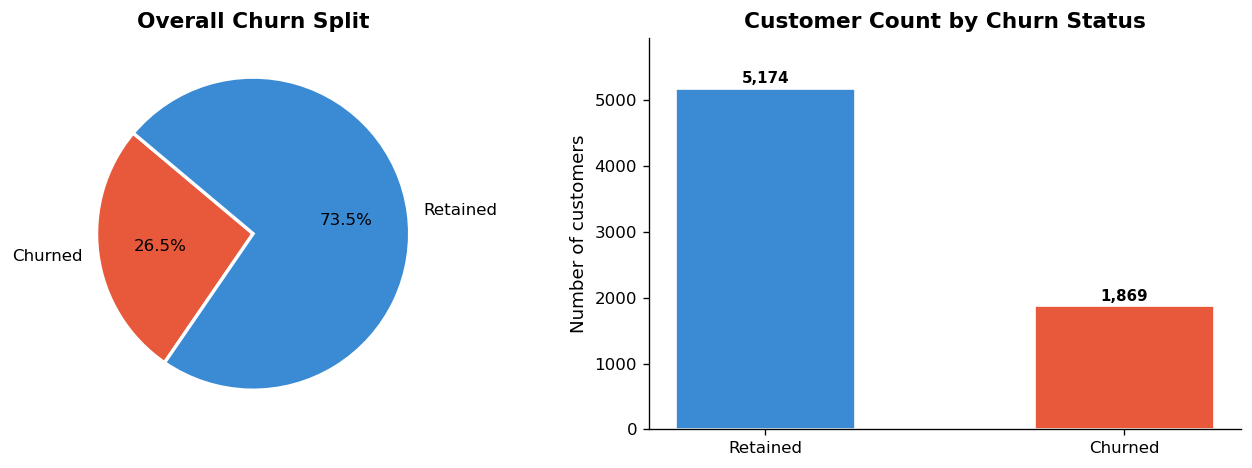

Chart 01 saved ✓


In [3]:
# ── Chart 1: Overall churn split ──────────────────────────────────────────────
total    = len(df)
churned  = df['Churn_Binary'].sum()
retained = total - churned

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie(
    [churned, retained],
    labels=['Churned', 'Retained'],
    colors=[CHURN_COLOR, RETAIN_COLOR],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Churn Split')

# Bar
bars = axes[1].bar(
    ['Retained', 'Churned'], [retained, churned],
    color=[RETAIN_COLOR, CHURN_COLOR], width=0.5, edgecolor='white'
)
label_bars_v(axes[1], bars, fmt='{:,.0f}', pad=40)
axes[1].set_title('Customer Count by Churn Status')
axes[1].set_ylabel('Number of customers')
axes[1].set_ylim(0, retained * 1.15)

plt.tight_layout()
plt.savefig('../outputs/chart_01_churn_overview.png', bbox_inches='tight')
plt.show()
print('Chart 01 saved ✓')


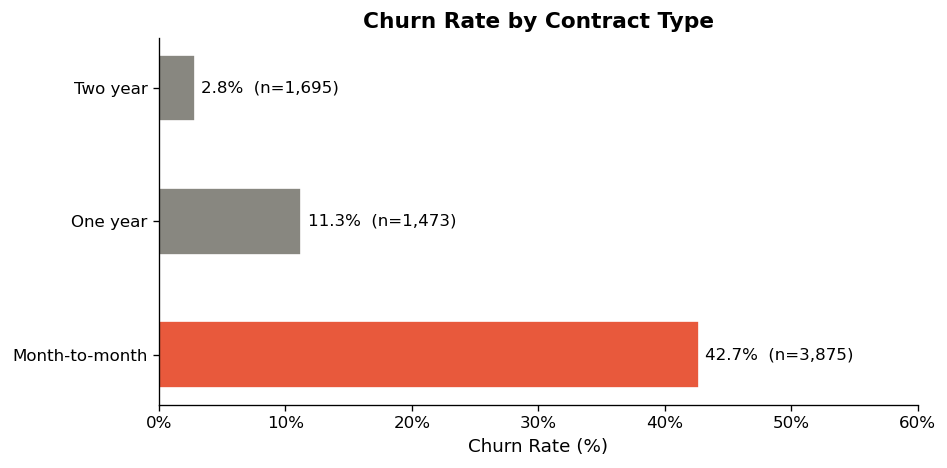

Chart 02 saved ✓


In [4]:
# ── Chart 2: Churn rate by contract type ─────────────────────────────────────
contract_churn = (
    df.groupby('Contract')['Churn_Binary']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Churn_Rate', 'count': 'Total'})
    .sort_values('Churn_Rate', ascending=False)
)
contract_churn['Churn_Pct'] = contract_churn['Churn_Rate'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
colors = [CHURN_COLOR if r > 20 else NEUTRAL_COLOR for r in contract_churn['Churn_Pct']]
bars = ax.barh(
    contract_churn['Contract'], contract_churn['Churn_Pct'],
    color=colors, edgecolor='white', height=0.5
)
for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Churn_Pct']:.1f}%  (n={row['Total']:,})",
        va='center', fontsize=10
    )
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
ax.set_xlim(0, 60)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../outputs/chart_02_contract_churn.png', bbox_inches='tight')
plt.show()
print('Chart 02 saved ✓')

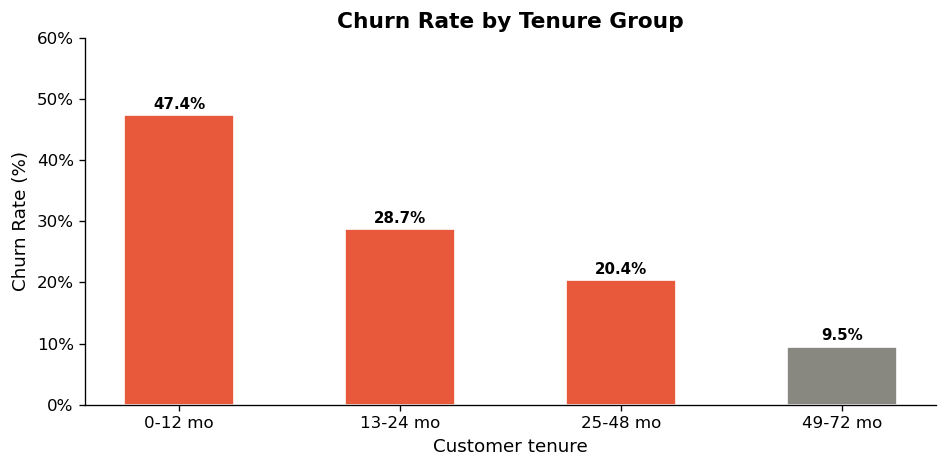

Chart 03 saved ✓


In [5]:
# ── Chart 3: Churn rate by tenure group ──────────────────────────────────────
tenure_churn = (
    df.groupby('Tenure_Group', observed=True)['Churn_Binary']
    .mean() * 100
).reset_index()
tenure_churn.columns = ['Tenure_Group', 'Churn_Rate']

fig, ax = plt.subplots(figsize=(8, 4))
colors = [CHURN_COLOR if r > 20 else NEUTRAL_COLOR for r in tenure_churn['Churn_Rate']]
bars = ax.bar(
    tenure_churn['Tenure_Group'].astype(str),
    tenure_churn['Churn_Rate'],
    color=colors, width=0.5, edgecolor='white'
)
label_bars_v(ax, bars)
ax.set_xlabel('Customer tenure')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tenure Group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('../outputs/chart_03_tenure_churn.png', bbox_inches='tight')
plt.show()
print('Chart 03 saved ✓')

In [ ]:
# ── Chart 4: Monthly charges distribution ────────────────────────────────────
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no  = df[df['Churn'] == 'No']['MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
bp = axes[0].boxplot(
    [churn_no, churn_yes],
    labels=['Retained', 'Churned'],
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2}
)
bp['boxes'][0].set_facecolor(RETAIN_COLOR)
bp['boxes'][1].set_facecolor(CHURN_COLOR)
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Monthly Charges by Churn Status')

# Histogram
axes[1].hist(churn_no,  bins=30, alpha=0.6, color=RETAIN_COLOR, label='Retained', edgecolor='white')
axes[1].hist(churn_yes, bins=30, alpha=0.7, color=CHURN_COLOR,  label='Churned',  edgecolor='white')
axes[1].axvline(churn_no.mean(),  color=RETAIN_COLOR, linestyle='--', linewidth=1.5, label=f'Retained avg ${churn_no.mean():.0f}')
axes[1].axvline(churn_yes.mean(), color=CHURN_COLOR,  linestyle='--', linewidth=1.5, label=f'Churned avg ${churn_yes.mean():.0f}')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Number of customers')
axes[1].set_title('Monthly Charges Distribution')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/chart_04_monthly_charges.png', bbox_inches='tight')
plt.show()
print(f'Churned avg: ${churn_yes.mean():.2f}  |  Retained avg: ${churn_no.mean():.2f}')

In [ ]:
# ── Chart 5: Internet service & payment method ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

def churn_rate_plot(ax, col, title, horizontal=False):
    data = (
        df.groupby(col)['Churn_Binary'].mean() * 100
    ).reset_index().sort_values('Churn_Binary', ascending=horizontal)
    data.columns = [col, 'Churn_Rate']
    colors = [CHURN_COLOR if r > 20 else NEUTRAL_COLOR for r in data['Churn_Rate']]
    if horizontal:
        bars = ax.barh(data[col], data['Churn_Rate'], color=colors, edgecolor='white', height=0.5)
        label_bars_h(ax, bars)
        ax.set_xlabel('Churn Rate (%)')
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_xlim(0, 60)
    else:
        bars = ax.bar(data[col], data['Churn_Rate'], color=colors, edgecolor='white', width=0.5)
        label_bars_v(ax, bars)
        ax.set_ylabel('Churn Rate (%)')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylim(0, 55)
    ax.set_title(title)

churn_rate_plot(axes[0], 'InternetService', 'Churn Rate by Internet Service')
churn_rate_plot(axes[1], 'PaymentMethod',   'Churn Rate by Payment Method', horizontal=True)

plt.tight_layout()
plt.savefig('../outputs/chart_05_internet_payment.png', bbox_inches='tight')
plt.show()
print('Chart 05 saved ✓')

In [ ]:
# ── Chart 6: Demographics ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['gender', 'SeniorCitizen_Label', 'Partner'],
    ['Churn by Gender', 'Churn by Senior Citizen', 'Churn by Partnership Status']
):
    data = (df.groupby(col)['Churn_Binary'].mean() * 100).reset_index()
    data.columns = [col, 'Churn_Rate']
    colors = [CHURN_COLOR if r > 20 else NEUTRAL_COLOR for r in data['Churn_Rate']]
    bars = ax.bar(data[col], data['Churn_Rate'], color=colors, width=0.4, edgecolor='white')
    label_bars_v(ax, bars)
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig('../outputs/chart_06_demographics.png', bbox_inches='tight')
plt.show()
print('Chart 06 saved ✓')

In [ ]:
# ── Chart 7: Correlation heatmap ──────────────────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Binary']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('../outputs/chart_07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('=== Correlation with Churn (sorted) ===')
churn_corr = corr['Churn_Binary'].drop('Churn_Binary').sort_values(key=abs, ascending=False)
for feat, val in churn_corr.items():
    print(f'  {feat:<20} r = {val:+.3f}  → {"higher" if val>0 else "lower"} churn')
print('Chart 07 saved ✓')

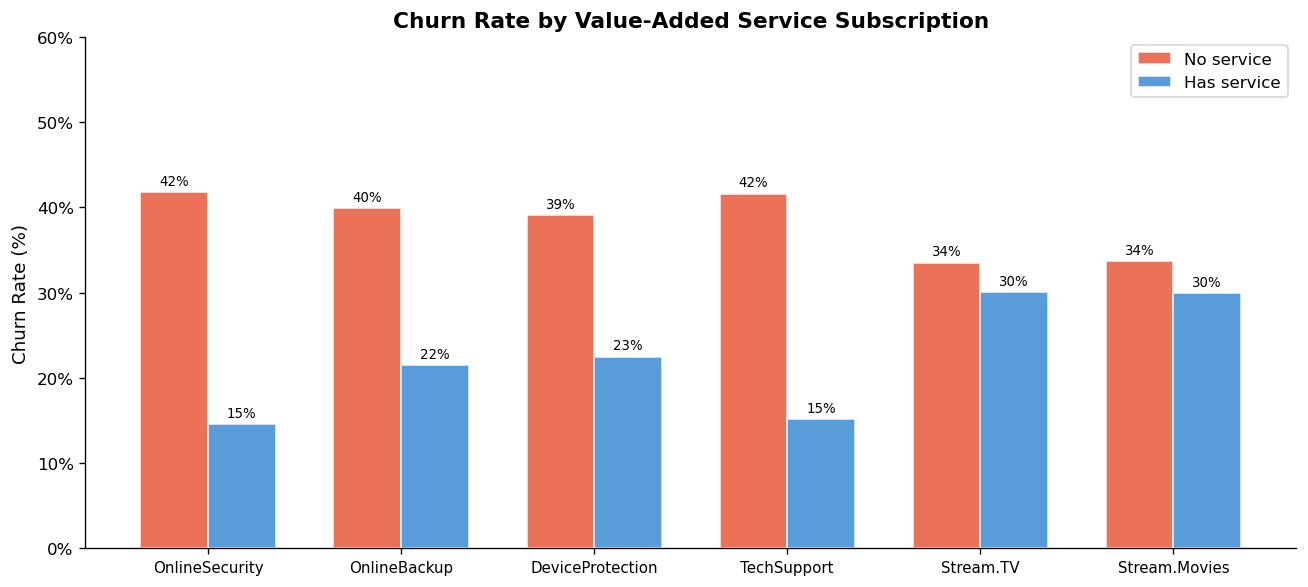

Chart 08 saved ✓

All 8 charts saved → eda-insights/outputs/
Next → open 03_insights_summary.ipynb


In [6]:
# ── Chart 8: Value-added services ─────────────────────────────────────────────
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

rows = []
for col in service_cols:
    for val in ['Yes', 'No']:
        subset = df[df[col] == val]
        rows.append({'Service': col, 'Has_Service': val, 'Churn_Rate': subset['Churn_Binary'].mean() * 100})
svc_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(service_cols))
width = 0.35

yes_rates = svc_df[svc_df['Has_Service'] == 'Yes']['Churn_Rate'].values
no_rates  = svc_df[svc_df['Has_Service'] == 'No']['Churn_Rate'].values

bars_no  = ax.bar(x - width/2, no_rates,  width, label='No service',  color=CHURN_COLOR,  edgecolor='white', alpha=0.85)
bars_yes = ax.bar(x + width/2, yes_rates, width, label='Has service', color=RETAIN_COLOR, edgecolor='white', alpha=0.85)

for bar in list(bars_no) + list(bars_yes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.0f}%',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels([c.replace('Streaming', 'Stream.') for c in service_cols], fontsize=9)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Value-Added Service Subscription')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('../outputs/chart_08_services_churn.png', bbox_inches='tight')
plt.show()
print('Chart 08 saved ✓')
print('\nAll 8 charts saved → eda-insights/outputs/')
print('Next → open 03_insights_summary.ipynb')